# Figure 2: Plot FESOM1.4 snapshots (and means)

## Imports & Data Loading

In [5]:
# General
import xarray as xr
import numpy as np
import pandas as pd
import sys

# Plotting
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cmo
from matplotlib import ticker

# FESOM
import pyfesom as pf
sys.path.append("/albedo/home/quraus001/FESOM-FS-subduction/functions/")
import FESOM_processing as fprc

from matplotlib.font_manager import FontProperties
font_bold_cond = '/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-BOLDCOND.OTF' 
font_cond = '/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-COND.OTF' 
font_bold = '/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-BOLD.OTF' 
font      = "/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-REGULAR.OTF"

## Load Data

In [6]:
plotpath = "/albedo/work/user/quraus001/FESOM_particles/analysis/plots/paper/"

meshpath = "/albedo/home/quraus001/Arc08_sub/"
bafufile = "/albedo/work/user/quraus001/FESOM_particles/preparation/bafux_bafuy_2d.nc"

bathfile = "/albedo/work/user/quraus001/bath/ETOPO_2022_v1_60s_N90W180_bed.nc"
icefile  = "/albedo/work/projects/oce_rio/cwekerle/result/Arc40/from_1988_erai/Arc40.2006.ice.mean.sub.nc"
ocefile  = "/albedo/work/projects/oce_rio/cwekerle/result/Arc40/from_1988_erai/Arc40.2006.oce.mean.sub.nc"
ocefile_mean = "/albedo/work/user/quraus001/FESOM_particles/result/processed_results/Arc40_2006-2007_oce_yseasmean.nc"

In [5]:
# Generate the seasonal mean ocean file with CDO
if False:
    from cdo import Cdo
    cdo = Cdo()

    infiles = ["/albedo/work/projects/oce_rio/cwekerle/result/Arc40/from_1988_erai/Arc40.2006.oce.mean.sub.nc", 
            "/albedo/work/projects/oce_rio/cwekerle/result/Arc40/from_1988_erai/Arc40.2007.oce.mean.sub.nc"]
    cdo.yseasmean(input=f"-mergetime {infiles[0]} {infiles[1]}", output=ocefile_mean)

In [7]:
# Bathymetry
ds_bath = xr.open_dataset(bathfile)
# select only reagion of interest
ds_bath = ds_bath.sel(lon=slice(-40, 40), lat=slice(65, 90))

# FESOM mesh
mesh = pf.load_mesh(meshpath)
al, be, ga = mesh.alpha, mesh.beta, mesh.gamma

# Basis Function
ds_bafu = xr.open_dataset(bafufile)

# Ice Daily
ds_ice = xr.open_dataset(icefile)
ds_ice = ds_ice.isel(time=[0,181]) # select 1st Jan & 1st July

# Ocean Daily
ds_oce = fprc.load_FESOM_data_with_grid(meshpath, ocefile)
ds_oce = ds_oce.isel(time=[0,181]) # select 1st Jan & 1st July

# Ocean Seasonal Mean
ds_oce_mean = fprc.load_FESOM_data_with_grid(meshpath, ocefile_mean)

/albedo/home/quraus001/Arc08_sub/pickle_mesh_py3
3
The usepickle == True)
The pickle file for python 3 exists.
The mesh will be loaded from /albedo/home/quraus001/Arc08_sub/pickle_mesh_py3


## Select & Calculate Fields

In [8]:
sic1 = ds_ice.area.isel(time=0).values * 100
sic2 = ds_ice.area.isel(time=1).values * 100

depth = 10 # model level for 100m depth
temp1 = fprc.reshape_3d_nodes(ds_oce, var="temp", time_idx=0, fill_value = -999)[:,depth] # convert (3d_nodes) into (2d_nodes, depth)
temp2 = fprc.reshape_3d_nodes(ds_oce, var="temp", time_idx=1, fill_value = -999)[:,depth]

# Calculate average Speed
Speeds_mean, Us_mean, Vs_mean = [], [], []
for t in [0,2]:
    u = fprc.reshape_3d_nodes(ds_oce_mean, var="u", time_idx=t, fill_value = np.nan)[:,depth]
    v = fprc.reshape_3d_nodes(ds_oce_mean, var="v", time_idx=t, fill_value = np.nan)[:,depth]

    u_rot, v_rot = pf.vec_rotate_r2g(al, be, ga , mesh.x2, mesh.y2, u, v, flag=1)
    speed = np.sqrt(u_rot**2 + v_rot**2)
    Speeds_mean.append(speed)
    Us_mean.append(u_rot)
    Vs_mean.append(v_rot)

In [9]:
df_elem = pd.read_csv(meshpath + 'elem2d.out', sep='\s+', header=None, skiprows=1) # load element to nodes look up table
df_elem.columns = ['node1', 'node2', 'node3']
elem_back = df_elem.to_numpy().T # columns to 3x el2d matrix
elem_back -= 1                   # convert to python counting

def calc_derivative(vx2d, ds, elem_back, n2d):
    bafux_2d = ds.bafux_2d.values
    bafuy_2d = ds.bafuy_2d.values
    voltriangle = ds.voltriangle.values
    full_cluster_area = ds.full_cluster_area.values

    # Step 1: Pull values of vx2d at triangle nodes
    vx_elem = vx2d[elem_back]  # shape: (3, el2d)

    # Step 2: Compute derivatives in each triangle using basis function gradients
    vari_deriv_el_x = np.sum(vx_elem * bafux_2d, axis=0)  # shape: (el2d,)
    vari_deriv_el_y = np.sum(vx_elem * bafuy_2d, axis=0)  # shape: (el2d,)

    # Step 3: Initialize nodal derivatives
    vari_deriv_nod_x = np.zeros(n2d)
    vari_deriv_nod_y = np.zeros(n2d)

    # Step 4: Accumulate area-weighted triangle derivatives to each node
    np.add.at(vari_deriv_nod_x, elem_back[0], vari_deriv_el_x * voltriangle)
    np.add.at(vari_deriv_nod_x, elem_back[1], vari_deriv_el_x * voltriangle)
    np.add.at(vari_deriv_nod_x, elem_back[2], vari_deriv_el_x * voltriangle)

    np.add.at(vari_deriv_nod_y, elem_back[0], vari_deriv_el_y * voltriangle)
    np.add.at(vari_deriv_nod_y, elem_back[1], vari_deriv_el_y * voltriangle)
    np.add.at(vari_deriv_nod_y, elem_back[2], vari_deriv_el_y * voltriangle)

    # Step 5: Normalize by total area (to get area-weighted mean derivative at each node)
    vari_deriv_nod_x /= full_cluster_area
    vari_deriv_nod_y /= full_cluster_area
    return vari_deriv_nod_x, vari_deriv_nod_y


def calc_vorticity(u,v, ds, elem_back, n2d):
    # Calculate derivatives
    du_dx, du_dy = calc_derivative(u, ds, elem_back, n2d)
    dv_dx, dv_dy = calc_derivative(v, ds, elem_back, n2d)

    # Calculate vorticity
    vorticity = dv_dx - du_dy
    return vorticity

Vorts = []
Us, Vs = [], []
depth = 10
for t in range(2):
    u = fprc.reshape_3d_nodes(ds_oce, var="u", time_idx=t, fill_value = np.nan)[:,depth]
    v = fprc.reshape_3d_nodes(ds_oce, var="v", time_idx=t, fill_value = np.nan)[:,depth]

    u_rot, v_rot = pf.vec_rotate_r2g(al, be, ga , mesh.x2, mesh.y2, u, v, flag=1)

    vorticity = calc_vorticity(u_rot, v_rot, ds_bafu, elem_back, mesh.n2d)
    Vorts.append(vorticity)
    Us.append(u_rot)
    Vs.append(v_rot)

/tmp/ipykernel_574600/42338943.py:33: RuntimeWarning: invalid value encountered in divide
  vari_deriv_nod_x /= full_cluster_area
/tmp/ipykernel_574600/42338943.py:34: RuntimeWarning: invalid value encountered in divide
  vari_deriv_nod_y /= full_cluster_area


## Grid for Plotting

Also works without gridding with plt.tri... but takes like 10 times longer than regridding and plotting...

In [10]:
# Regridding makes plottig much faster sadly...

lon_grid = np.arange(-30, 40, 0.02)
lat_grid = np.arange(60, 85, 0.02)

grid_out = xr.Dataset({
    'lon': (['lon'], lon_grid),
    'lat': (['lat'], lat_grid),
})

lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

temp1_grid = pf.fesom2regular(temp1, mesh, lon_mesh, lat_mesh , how='nn') #idist oder so
temp2_grid = pf.fesom2regular(temp2, mesh, lon_mesh, lat_mesh , how='nn')
print("gridded temp")


sic1_grid = pf.fesom2regular(sic1, mesh, lon_mesh, lat_mesh , how='nn')
sic2_grid = pf.fesom2regular(sic2, mesh, lon_mesh, lat_mesh , how='nn')
print("gridded sic")

vort1_grid = pf.fesom2regular(Vorts[0], mesh, lon_mesh, lat_mesh , how='nn')
vort2_grid = pf.fesom2regular(Vorts[1], mesh, lon_mesh, lat_mesh , how='nn')
print("gridded vort")

speed1_grid = pf.fesom2regular(Speeds_mean[0], mesh, lon_mesh, lat_mesh , how='nn')
speed2_grid = pf.fesom2regular(Speeds_mean[1], mesh, lon_mesh, lat_mesh , how='nn')
print("gridded speed")

#temp1_grid[lsmask] = np.nan  # Set land points to NaN

gridded temp
gridded sic
gridded vort
gridded speed


In [11]:
# Divide by coriolis parameter
vort1_grid /= (np.pi *2 / 86164 *2 * np.sin(np.radians(lat_mesh)))
vort2_grid /= (np.pi *2 / 86164 *2 * np.sin(np.radians(lat_mesh)))

## Prepare Quiver

In [12]:
# Cartopy fix https://github.com/SciTools/cartopy/issues/1179
subsample = 500

def quiver_fix(u_mean, v_mean, subsample):
    u_ctrl = u_mean#Us_mean[0]
    v_ctrl = v_mean#Vs_mean[0]
    u_src_crs = u_ctrl / np.cos(mesh.y2/ 180 * np.pi)
    v_src_crs = v_ctrl
    magnitude = np.sqrt(u_ctrl**2 + v_ctrl**2)
    magn_src_crs = np.sqrt(u_src_crs**2 + v_src_crs**2)

    
    #u_real = u[0,:]#/np.cos(mesh.y2[mask]/ 180 * np.pi)
    u_real = u_src_crs * magnitude / magn_src_crs
    v_real = v_src_crs * magnitude / magn_src_crs
    U_sub = u_real[::subsample]
    V_sub = v_real[::subsample]
    return U_sub, V_sub

lon_sub = mesh.x2[::subsample]
lat_sub = mesh.y2[::subsample]

U_sub_1, V_sub_1 = quiver_fix(Us_mean[0], Vs_mean[0], subsample)
U_sub_2, V_sub_2 = quiver_fix(Us_mean[1], Vs_mean[1], subsample)

desired_arrow_length = .8  # in axes units (tune visually)
scale = 1 / desired_arrow_length

/tmp/ipykernel_574600/4010230096.py:14: RuntimeWarning: invalid value encountered in divide
  u_real = u_src_crs * magnitude / magn_src_crs
/tmp/ipykernel_574600/4010230096.py:15: RuntimeWarning: invalid value encountered in divide
  v_real = v_src_crs * magnitude / magn_src_crs


## Plot

In [13]:
def set_cbar_font(cbar, font_prop, fontsize, clabel):
    cbar.set_label(clabel, fontproperties=font_prop, fontsize=fontsize)

    for label in cbar.ax.get_yticklabels():
        label.set_fontproperties(font_prop)
        label.set_fontsize(fontsize)

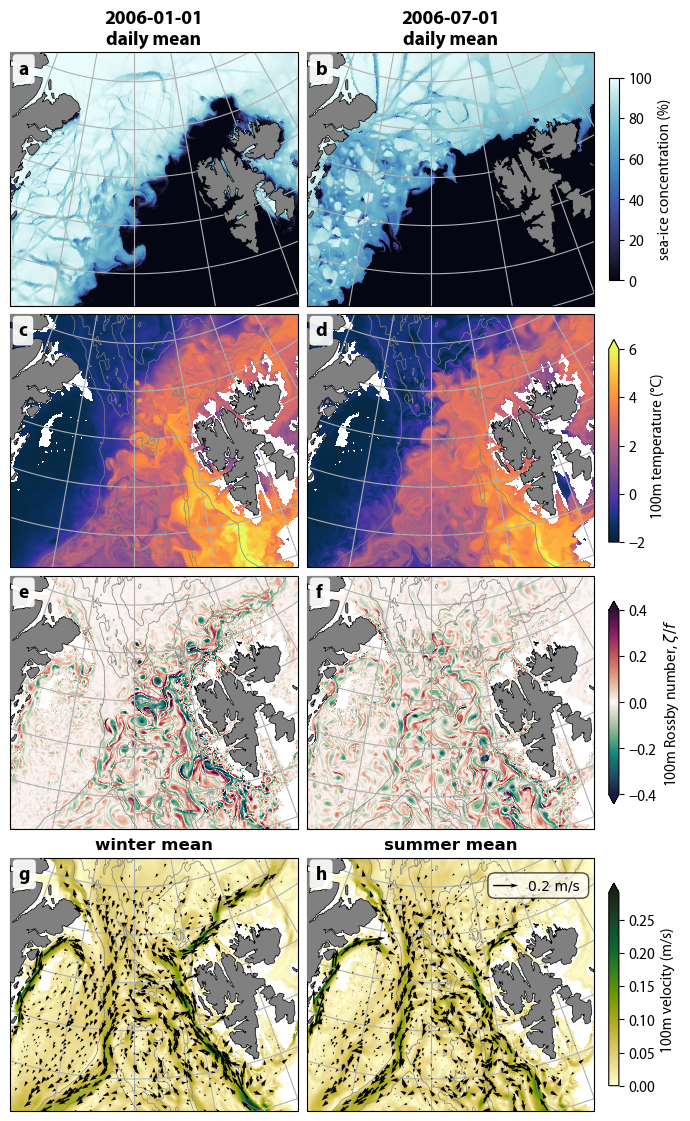

In [18]:
fig, axs = plt.subplots(4,2, subplot_kw={'projection': ccrs.NorthPolarStereo()}, figsize=(6.8,11.1), constrained_layout=True)
cbar_shrink=0.8
font_prop = FontProperties(fname=font)
font_prop_bold = FontProperties(fname=font_bold)
fontsize = 11

for ax in axs.flatten():
    ax.set_extent([-15, 20, 75, 83], crs=ccrs.PlateCarree())
    ax.gridlines()
    ax.add_feature(cfeature.LAND, facecolor="grey", zorder=9, edgecolor="black", linewidth=0.5)

axs[0,0].set_title("2006-01-01\ndaily mean", fontproperties=font_prop_bold, fontsize=14)
axs[0,1].set_title("2006-07-01\ndaily mean", fontproperties=font_prop_bold, fontsize=14)

if True: # SIC & temperature
    im1 = axs[0,0].pcolormesh(lon_grid, lat_grid, sic1_grid, transform=ccrs.PlateCarree(), cmap=cmo.cm.ice, vmin=0, vmax=100)
    axs[0,1].pcolormesh(lon_grid, lat_grid, sic2_grid, transform=ccrs.PlateCarree(), cmap=cmo.cm.ice, vmin=0, vmax=100)
    cbar1 = fig.colorbar(im1, ax=axs[0,1], orientation="vertical", shrink=cbar_shrink)
    set_cbar_font(cbar1, font_prop, fontsize, "sea-ice concentration (%)")


    im2 = axs[1,0].pcolormesh(lon_grid, lat_grid, temp1_grid, transform=ccrs.PlateCarree(), cmap=cmo.cm.thermal, vmin=-2, vmax=6)
    axs[1,1].pcolormesh(lon_grid, lat_grid, temp2_grid, transform=ccrs.PlateCarree(), cmap=cmo.cm.thermal, vmin=-2, vmax=6)
    cbar2 = fig.colorbar(im2, ax=axs[1,1], orientation="vertical", shrink=cbar_shrink, extend="max")
    set_cbar_font(cbar2, font_prop, fontsize, "100m temperature (°C)")

if True: # Vorticity
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1, 1)) # Erzwingt Sci-Notation außerhalb von 0.1 - 10

    im3 = axs[2,0].pcolormesh(lon_grid, lat_grid, vort1_grid, transform=ccrs.PlateCarree(), cmap=cmo.cm.curl, vmin=-0.4, vmax=0.4)
    axs[2,1].pcolormesh(lon_grid, lat_grid, vort2_grid, transform=ccrs.PlateCarree(), cmap=cmo.cm.curl, vmin=-0.4, vmax=0.4)
    cbar3 = fig.colorbar(im3, ax=axs[2,1], orientation="vertical", shrink=cbar_shrink, extend="both")
    set_cbar_font(cbar3, font_prop, fontsize, r"100m Rossby number, $\zeta/f$")


    #cbar3.ax.yaxis.set_major_formatter(formatter)
    #cbar3.ax.yaxis.get_offset_text().set_verticalalignment('bottom')
    #cbar3.ax.yaxis.get_offset_text().set_horizontalalignment('center')
    #cbar3.ax.yaxis.get_offset_text().set_x(3) # Centers it horizontally over the bar
    #cbar3.ax.yaxis.get_offset_text().set_y(5) 

if True: # Quiver and speed
    axs[3,0].set_title("winter mean", fontweight="bold")
    axs[3,1].set_title("summer mean", fontweight="bold")
    im4 = axs[3,0].pcolormesh(lon_grid, lat_grid, speed1_grid, transform=ccrs.PlateCarree(), cmap=cmo.cm.speed)#, vmin=-0.0001, vmax=0.0001)
    axs[3,1].pcolormesh(lon_grid, lat_grid, speed2_grid, transform=ccrs.PlateCarree(), cmap=cmo.cm.speed)#, vmin=-0.0001, vmax=0.0001)
    cbar4 = fig.colorbar(im4, ax=axs[3,1], orientation="vertical", label="100m velocity (m/s)", shrink=cbar_shrink, extend="max")
    set_cbar_font(cbar4, font_prop, fontsize, "100m velocity (m/s)")



    quiver_kwargs = {
    'transform': ccrs.PlateCarree(),
    'scale': 0.8,
    'scale_units': 'inches',   
    'angles': 'xy',
    'width': 0.005,
    'color': 'black',
    'zorder': 100,
    'minlength': 0
}
    
    q = axs[3,0].quiver(lon_sub, lat_sub, U_sub_1, V_sub_1, **quiver_kwargs)

    q = axs[3,1].quiver(lon_sub, lat_sub, U_sub_2, V_sub_2, **quiver_kwargs)

    # 2. Use FancyBboxPatch for rounded corners
    # The 'boxstyle' argument controls the roundness ('pad' and 'rounding_size')
    rect = patches.FancyBboxPatch(
        (0.05, 0.72), 0.22, 0.08, 
        boxstyle="round,pad=0.02,rounding_size=0.05",
        transform=axs[3,0].transAxes, 
        facecolor='white', 
        edgecolor='black', 
        alpha=0.7, 
        zorder=80
    )

    # After creating qk, remove it and re-add to an overlay axes
    qk = axs[3,0].quiverkey(q, 0.12, 0.75, 0.2, "0.2 m/s", labelpos='E')
    qk.remove()

    # Create a tiny invisible overlay axes at the same position
    pos = axs[3,0].get_position()
    ax_overlay = fig.add_axes(pos, frameon=False)
    ax_overlay.set_xlim(0, 1)
    ax_overlay.set_ylim(0, 1)
    ax_overlay.axis('off')

    # Add quiverkey and box to overlay (always on top of everything)
    qk2 = ax_overlay.quiverkey(q, 0.735, 0.89, 0.2, "0.2 m/s", labelpos='E')

    rect = patches.FancyBboxPatch(
    (0.65, 0.86), 0.31, 0.06,
    boxstyle="round,pad=0.02,rounding_size=0.025",
    transform=axs[3,1].transAxes,  # <-- back to the map axes
    facecolor='white', edgecolor='black', alpha=0.7,
    zorder=101  # just needs to be > land zorder (2) and < quiverkey
    )
    axs[3,1].add_patch(rect)


# Add bathymetry
for ax in axs[1:,:].flatten():
    ax.contour(
            ds_bath.lon.values[::8], ds_bath.lat.values[::4], ds_bath.z.values[::4, ::8] * -1, linewidths=0.5,
            levels=[1000, 3000, 5000], colors=["grey", "grey", "grey"],
            transform=ccrs.PlateCarree(),# zorder=2
        )


# Add subplot labels
letters = ["a", "b", "c", "d", "e", r"f$\,$", "g", "h"]
for i, ax in enumerate(axs[:,:].flatten()):
        ax.text(
        0.03, 0.97, letters[i], 
        transform=ax.transAxes, 
        fontproperties=font_prop_bold,
        fontsize=14,  
        va='top', 
        ha='left',
        #backgroundcolor='white',
        zorder=100,
        bbox=dict(
            facecolor='white',     # White background
            alpha=0.9,             # 60% opaque (0 = transparent, 1 = solid)
            edgecolor='none',      # No harsh border line around the box
            boxstyle='round,pad=0.3,rounding_size=0.2' # Slightly rounded corners with a bit of padding
        )
    )

plt.savefig(plotpath + "WIP_FESOM-Overview.png", dpi=300)